In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("ASGN3/fashion-mnist_train.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.isna().sum()

label       0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Length: 785, dtype: int64

In [7]:
x_train=df.drop('label',axis=1)
# help(np.reshape)
x_train=np.array(x_train).reshape(x_train.shape[0],28,28)
y_train=df['label']
y_train=np.array(y_train)

In [8]:
# from tensorflow.keras.datasets import fashion_mnist
# (x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,MaxPool2D,Conv2D
from tensorflow.keras.losses import sparse_categorical_crossentropy

In [10]:
model=Sequential()
model.add(Conv2D(128,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPool2D())
model.add(Flatten())
model.add(Dropout(0.2))
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
# help(model.compile)

In [11]:
model.fit(x_train,y_train,epochs=2)

Epoch 1/2
1875/1875 [==============================] - 149s 78ms/step - loss: 1.0083 - accuracy: 0.8544
Epoch 2/2
1875/1875 [==============================] - 144s 77ms/step - loss: 0.2938 - accuracy: 0.8949


In [12]:
df=pd.read_csv("ASGN3/fashion-mnist_test.csv")
# df.head()
x_test=df.drop('label',axis=1)
# help(np.reshape)
x_test=np.array(x_test).reshape(x_test.shape[0],28,28)
y_test=df['label']
y_test=np.array(y_test)

In [13]:
model.evaluate(x_test,y_test)

313/313 [==============================] - 6s 17ms/step - loss: 0.2955 - accuracy: 0.8990


[0.2954736351966858, 0.8989999890327454]

In [14]:
y_pred=model.predict(x_test)

313/313 [==============================] - 7s 21ms/step


1/1 [==============================] - 0s 51ms/step


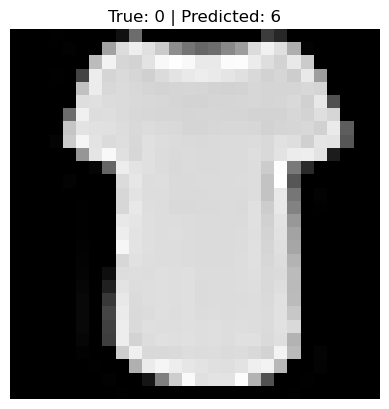

❌ Wrong! Model predicted 6, true label is 0


In [21]:
# Choose an index (e.g., 0 for the first test image)
index = 343

# Get the image and true label
image = x_test[index]
true_label = y_test[index]

# Predict the label (model expects a batch, so we add axis=0)
predicted_probabilities = model.predict(np.expand_dims(image, axis=0))
predicted_label = np.argmax(predicted_probabilities)

# Plot the image
plt.imshow(image, cmap='gray')
plt.title(f"True: {true_label} | Predicted: {predicted_label}")
plt.axis('off')
plt.show()

# Print result
if predicted_label == true_label:
    print(f"✅ Correct! Model predicted {predicted_label}, true label is {true_label}")
else:
    print(f"❌ Wrong! Model predicted {predicted_label}, true label is {true_label}")